# 9th feb

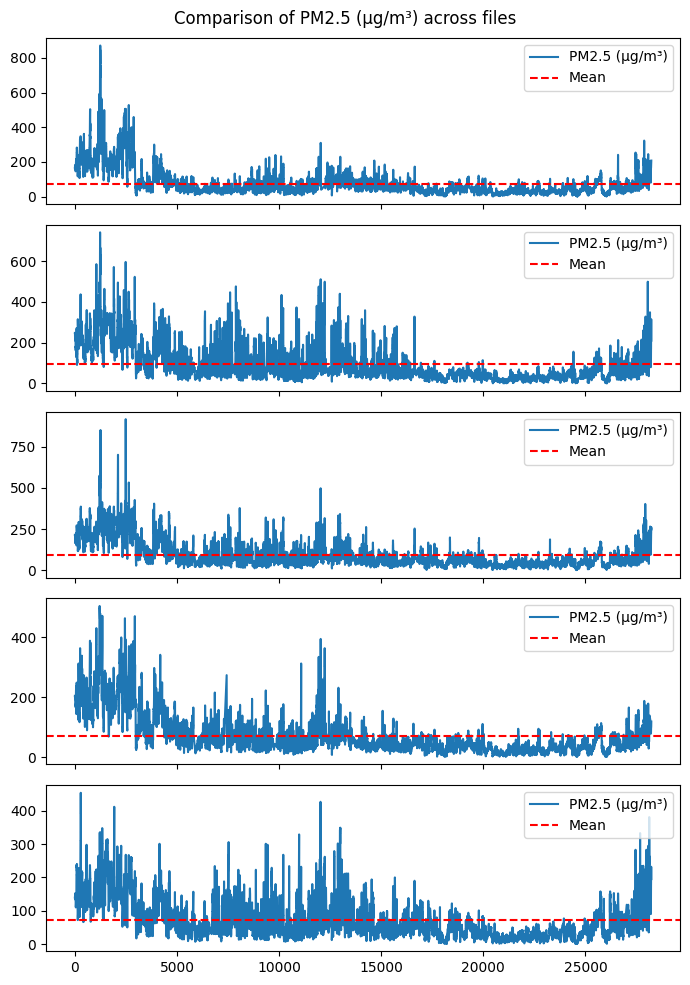

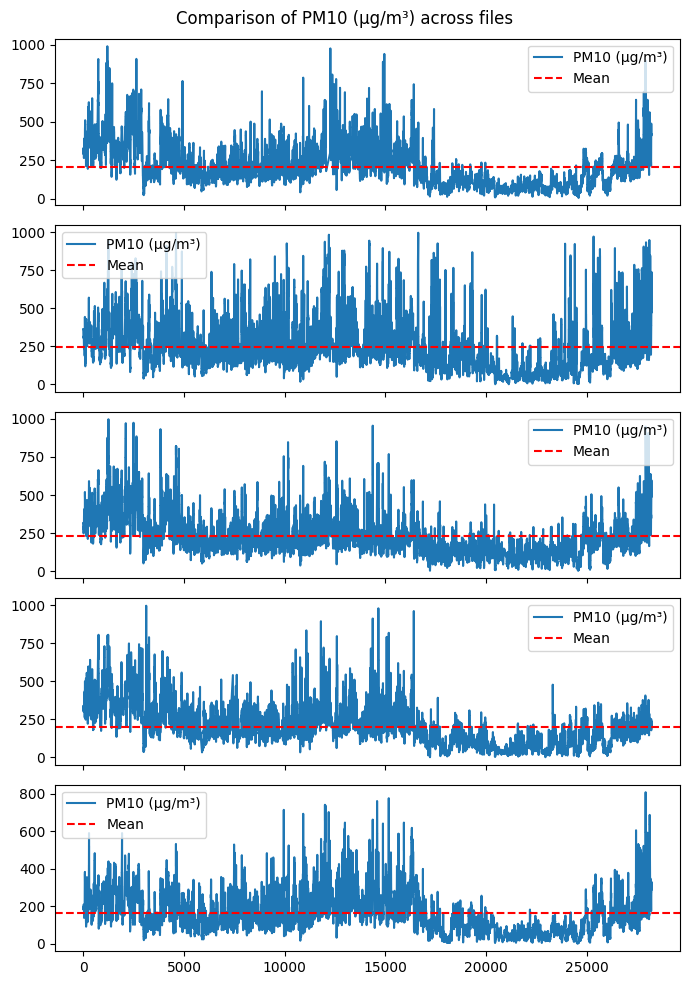

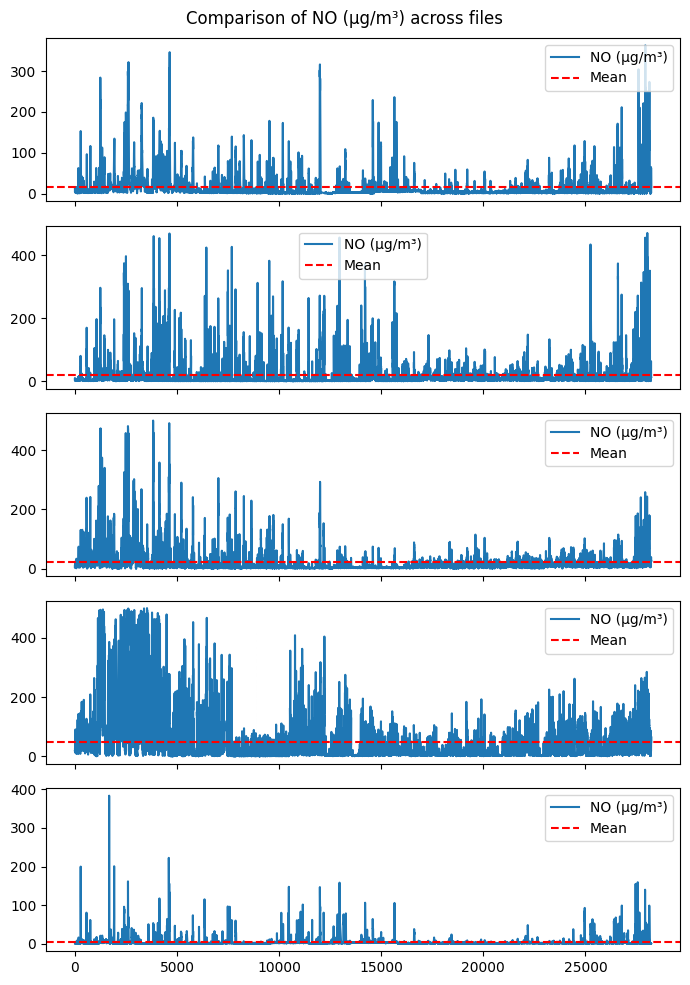

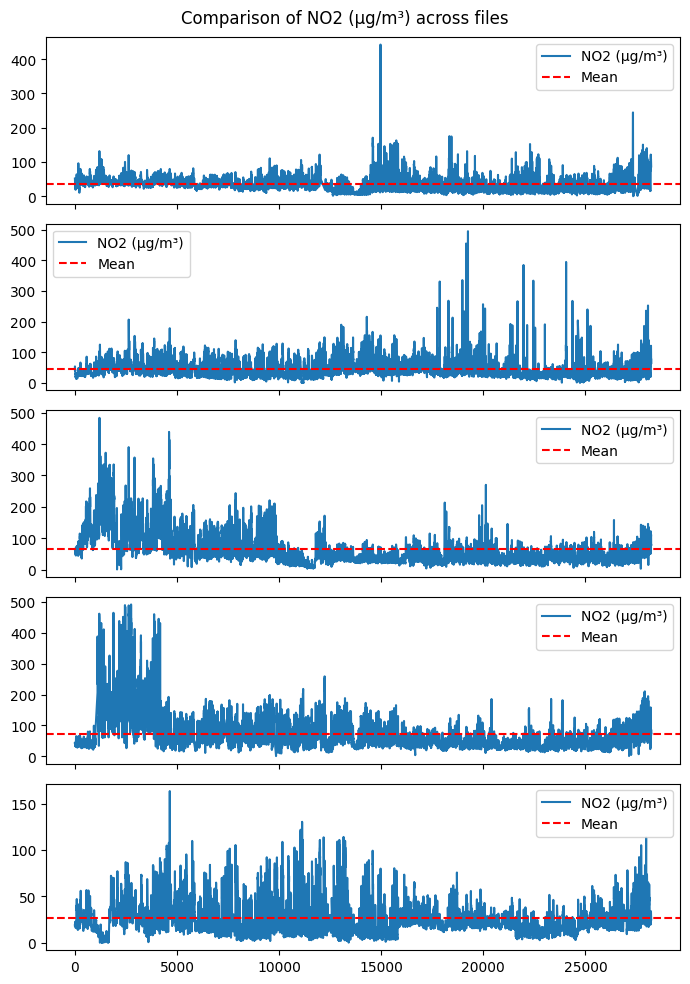

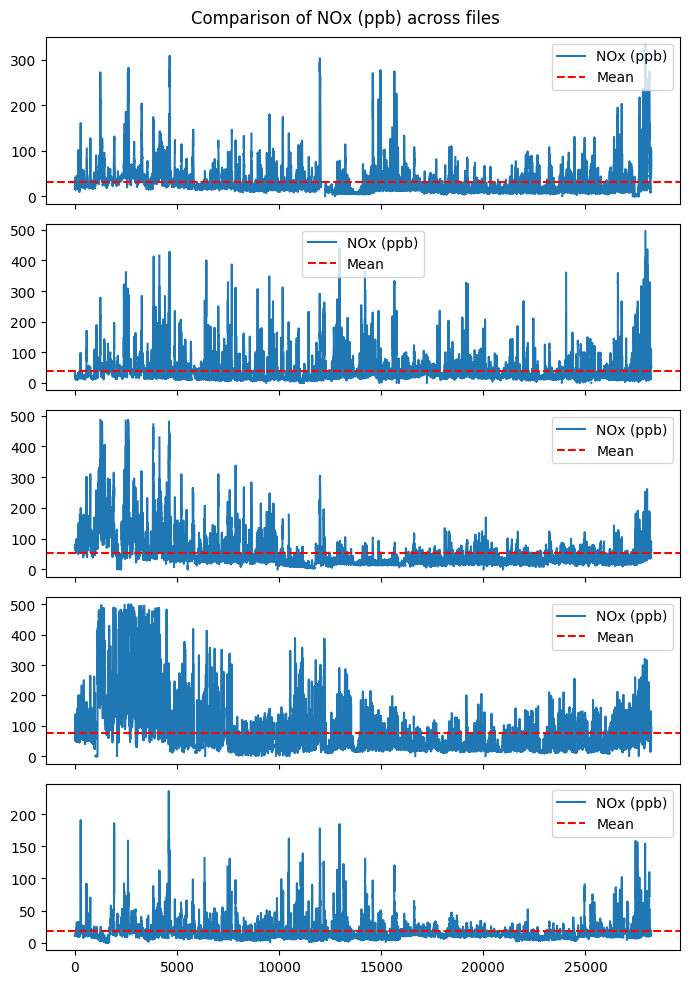

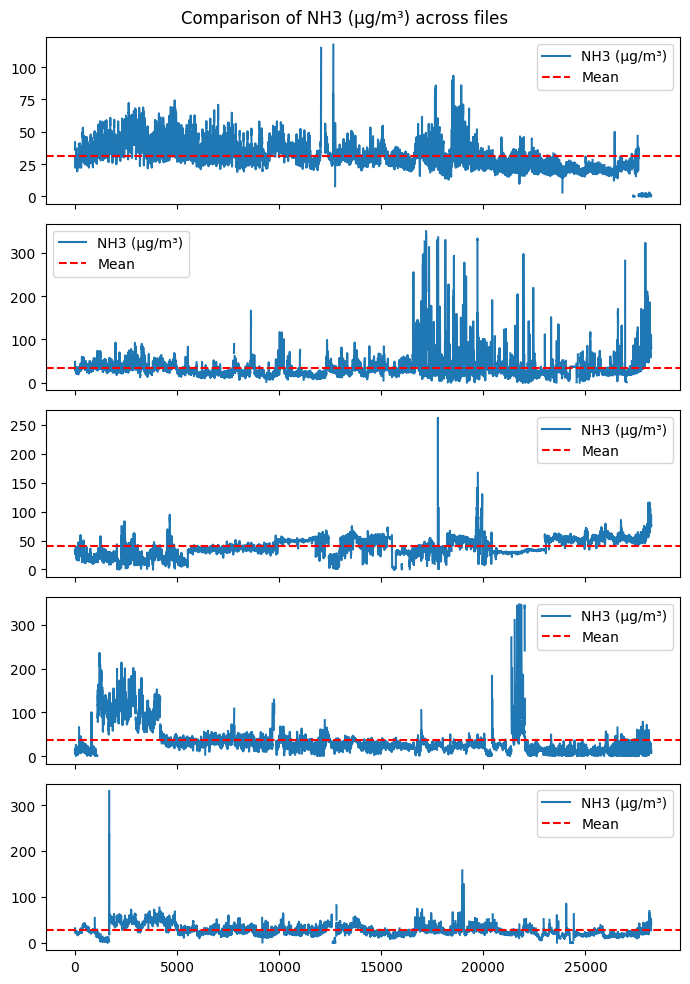

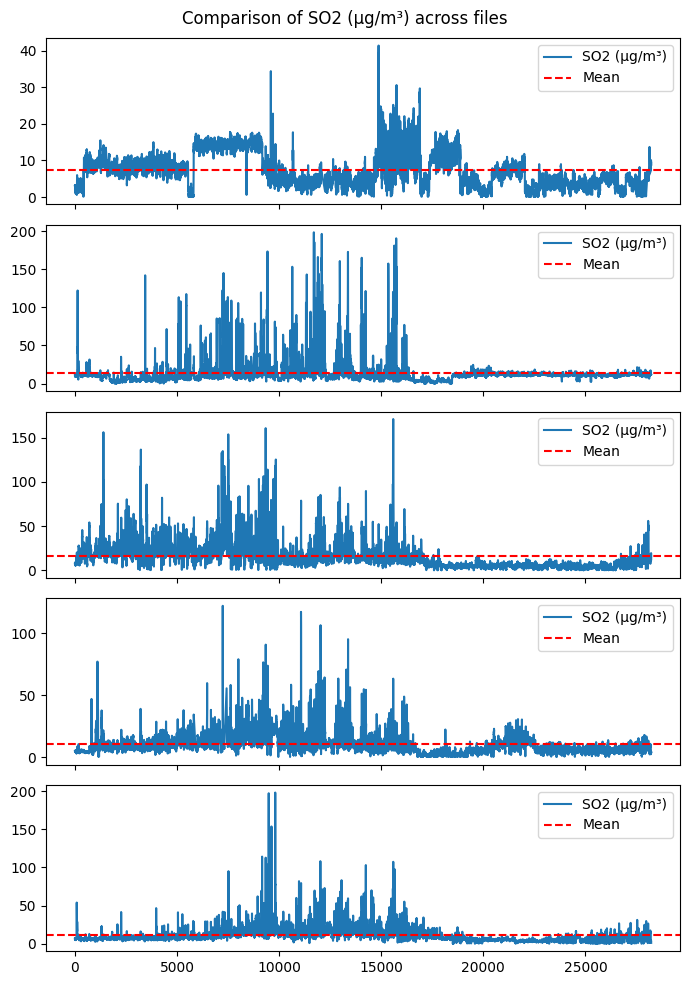

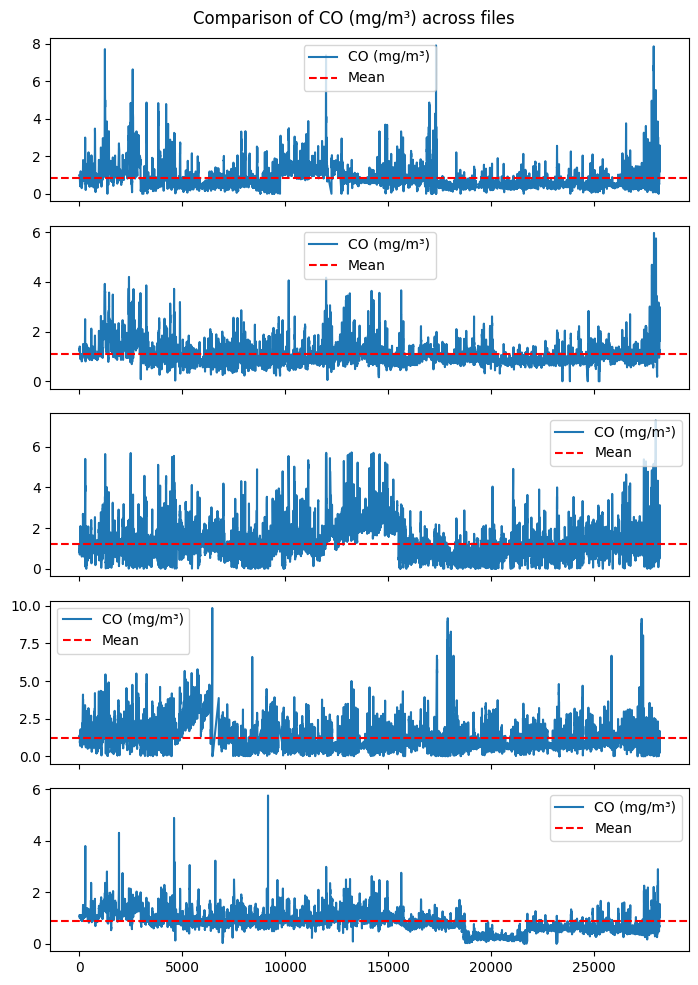

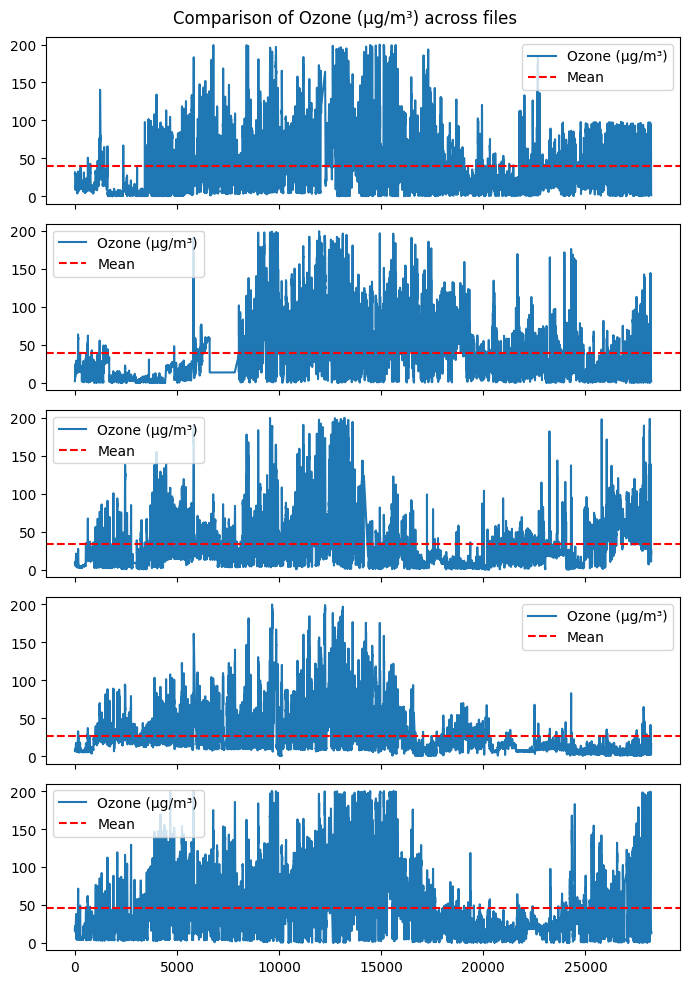

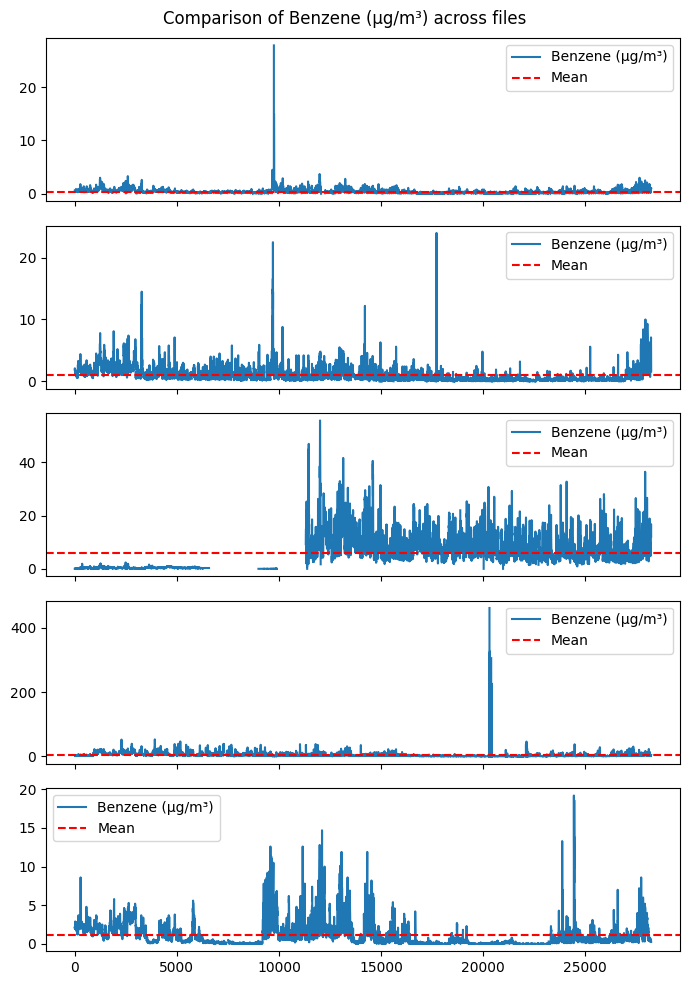

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

files = [
    'Non_Null_Datasets/preprocessed_Raw_data_15Min_2024_site_1431_Patparganj_Delhi_DPCC_15Min.csv',
    'Non_Null_Datasets/preprocessed_Raw_data_15Min_2024_site_1561_Mundka_Delhi_DPCC_15Min.csv',
    'Non_Null_Datasets/preprocessed_Raw_data_15Min_2024_site_1434_Wazirpur_Delhi_DPCC_15Min.csv',
    'Non_Null_Datasets/preprocessed_Raw_data_15Min_2024_site_1563_Pusa_Delhi_DPCC_15Min.csv',
    'Non_Null_Datasets/preprocessed_Raw_data_15Min_2024_site_5024_Alipur_Delhi_DPCC_15Min.csv'
]

df_list = [pd.read_csv(f) for f in files]

# Plot each column (other than the first) in separate figures,
# each figure has subplots (one subplot per file) for easy comparison.
for col in df_list[0].columns[1:11]:
    fig, axes = plt.subplots(nrows=len(df_list), ncols=1, figsize=(7, 10), sharex=True)
    fig.suptitle(f"Comparison of {col} across files")
    
    for i, (df_temp, fname) in enumerate(zip(df_list, files)):
        if col in df_temp.columns:
            axes[i].plot(df_temp[col], label=col)
            axes[i].axhline(y=df_temp[col].mean(), color='red', linestyle='--', label='Mean')
            # axes[i].set_ylabel(fname)
            axes[i].legend()
    
    plt.tight_layout()
    plt.show()

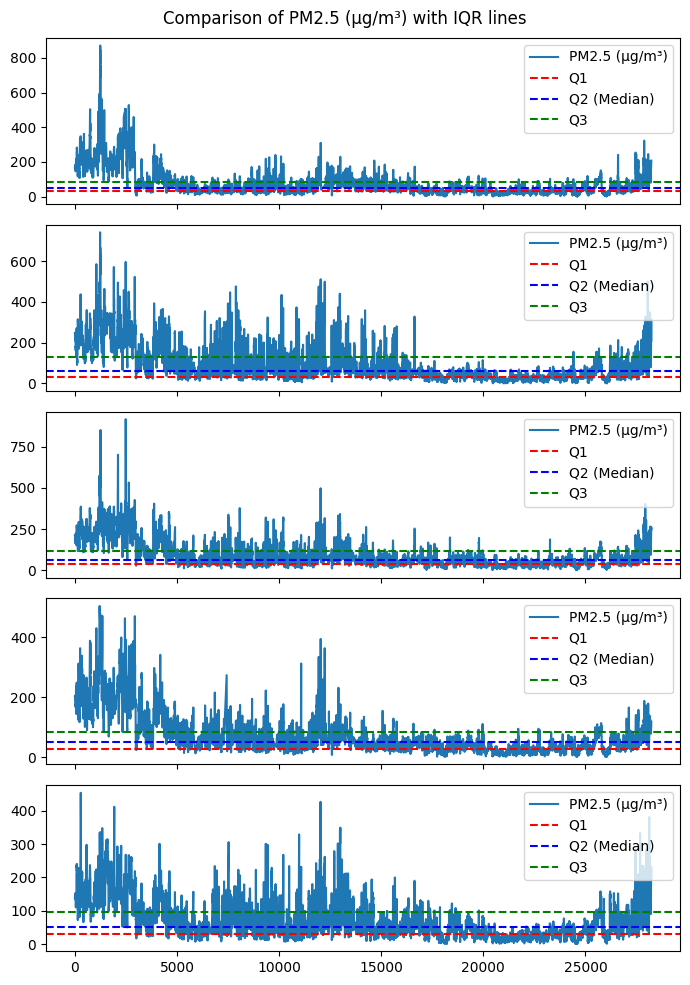

In [12]:
for col in df_list[3].columns[1:2]:

    fig, axes = plt.subplots(nrows=len(df_list), ncols=1, figsize=(7, 10), sharex=True)
    fig.suptitle(f"Comparison of {col} with IQR lines")
    
    for i, (df_temp, fname) in enumerate(zip(df_list, files)):
        if col in df_temp.columns:
            axes[i].plot(df_temp[col], label=col)
            q1 = df_temp[col].dropna().quantile(0.25)
            q2 = df_temp[col].dropna().quantile(0.5)  # Median (Q2)
            q3 = df_temp[col].dropna().quantile(0.75)
            axes[i].axhline(y=q1, color='red', linestyle='--', label='Q1')
            axes[i].axhline(y=q2, color='blue', linestyle='--', label='Q2 (Median)')
            axes[i].axhline(y=q3, color='green', linestyle='--', label='Q3')
            axes[i].legend()
    
    plt.tight_layout()
    plt.show()

In [ ]:
# import numpy as np
# import pandas as pd
# from scipy import stats
# import matplotlib.pyplot as plt

# class DelhiAQIScaler:
#     def __init__(self, data_path):
#         self.df = pd.read_csv(data_path)
#         self._preprocess()
#         self._calculate_baseline()
        
#     def _preprocess(self):
#         """Clean and prepare Delhi-specific data"""
#         self.df['aqi'] = self.df['aqi'].interpolate()
#         self.df = self.df.dropna()
        
#     def _calculate_baseline(self):
#         """Compute dynamic thresholds based on historical data"""
#         self.percentiles = {
#             'normal_low': np.percentile(self.df['aqi'], 25),
#             'normal_high': np.median(self.df['aqi']),
#             'alert': np.percentile(self.df['aqi'], 75),
#             'emergency': np.percentile(self.df['aqi'], 95)
#         }
        
#     def remap_aqi(self, current_aqi):
#         """Map current AQI to Delhi-specific categories"""
#         if current_aqi < self.percentiles['normal_low']:
#             return "Good (Delhi Standard)"
#         elif current_aqi < self.percentiles['normal_high']:
#             return "Satisfactory (Delhi Standard)"
#         elif current_aqi < self.percentiles['alert']:
#             return "Moderate Alert"
#         elif current_aqi < self.percentiles['emergency']:
#             return "Health Emergency"
#         else:
#             return "Critical Lockdown"
    
#     def visualize_distribution(self):
#         """Plot comparison of standard vs Delhi thresholds"""
#         plt.figure(figsize=(12,6))
#         plt.hist(self.df['aqi'], bins=50, density=True, alpha=0.7)
        
#         # Plot standard thresholds
#         std_thresholds = [50, 100, 200, 300, 400]
#         for t in std_thresholds:
#             plt.axvline(t, color='r', linestyle='--', alpha=0.5)
            
#         # Plot Delhi thresholds
#         colors = ['g', 'y', 'orange', 'r']
#         for i, (k,v) in enumerate(self.percentiles.items()):
#             plt.axvline(v, color=colors[i], linewidth=2)
            
#         plt.xlabel('AQI')
#         plt.ylabel('Frequency')
#         plt.title('Delhi-specific AQI Thresholds vs Standard')
#         plt.legend(['Standard Thresholds'] + list(self.percentiles.keys()))
#         plt.show()

# # Usage Example
# if __name__ == "__main__":
#     delhi_scaler = DelhiAQIScaler(files[0])
    
#     # Test with sample values
#     test_aqi = [80, 180, 250, 350, 450]
#     for aqi in test_aqi:
#         print(f"AQI {aqi}: {delhi_scaler.remap_aqi(aqi)}")
        
#     delhi_scaler.visualize_distribution()

In [3]:
DATA_PATH = 'Non_Null_Datasets/preprocessed_Raw_data_15Min_2024_site_1431_Patparganj_Delhi_DPCC_15Min.csv'

In [4]:
# %% Cell 1: Imports
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import json
import re
import joblib
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# %% Cell 2: Utility Functions
def clean_filename(name):
    """Sanitize filenames by removing special characters and replacing spaces."""
    parts = name.split()
    return parts[0]

# %% Cell 3: Load Data and Preprocess Function
def load_and_preprocess_data(file_path, target_pollutant, n_steps=4):
    """
    Load dataset, resample, scale, and structure it for time-series forecasting.
    Returns train-test split data along with the scaler.
    """
    df = pd.read_csv(file_path, parse_dates=['Timestamp'], index_col='Timestamp')
    
    # Define pollutants
    pollutants = [
        'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO (µg/m³)',
        'NO2 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)',
        'Ozone (µg/m³)'
    ]
    
    # Resample every 15 minutes and forward-fill missing values
    df = df[pollutants].resample('15T').mean().ffill()

    # Scale data
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df)

    # Create time-series dataset with sliding windows
    def create_dataset(data, n_steps):
        X, y = [], []
        for i in range(len(data) - n_steps):
            X.append(data[i:i + n_steps, :])  # Past n_steps as input
            y.append(data[i + n_steps, pollutants.index(target_pollutant)])  # Target pollutant
        return np.array(X), np.array(y)
    
    X, y = create_dataset(scaled_data, n_steps)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False, random_state=SEED
    )

    return (X_train, y_train), (X_test, y_test), scaler, df.shape[1]

# %% Cell 4: Model Building Function
def build_hybrid_model(input_shape, mlp_layers, lstm_layers, lstm_units, bidirectional):
    """
    Build and compile a hybrid MLP-LSTM model based on provided configuration.
    """
    model = tf.keras.Sequential()
    
    # MLP Layers
    model.add(tf.keras.layers.Flatten(input_shape=input_shape))
    for units in mlp_layers:
        model.add(tf.keras.layers.Dense(units, activation='relu'))
        model.add(tf.keras.layers.Dropout(0.2))
    
    # Reshape before LSTM
    model.add(tf.keras.layers.Reshape((1, -1)))  # Reshape to (1, features)

    # LSTM Layers
    for i in range(lstm_layers):
        return_sequences = i < (lstm_layers - 1)  # Return sequences for stacked LSTM
        if bidirectional:
            model.add(tf.keras.layers.Bidirectional(
                tf.keras.layers.LSTM(lstm_units, return_sequences=return_sequences)
            ))
        else:
            model.add(tf.keras.layers.LSTM(lstm_units, return_sequences=return_sequences))
        model.add(tf.keras.layers.Dropout(0.2))

    # Output Layer
    model.add(tf.keras.layers.Dense(1))

    # Compile Model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    return model
# %% Cell 5: Train and Save Best Models
def train_and_save_best_models(data_path, report_file='model_report.csv', models_dir='saved_models'):
    # Load best model configurations
    report_df = pd.read_csv(report_file)

    # Create directory to save models
    os.makedirs(models_dir, exist_ok=True)

    for _, row in report_df.iterrows():
        pollutant = row['Pollutant']
        clean_pollutant = clean_filename(pollutant)  # Sanitize pollutant name for filenames

        # Extract hyperparameters from report
        mlp_layers = eval(row['Best_Configuration'].split('MLP')[1].split('+')[0].strip())
        lstm_info = row['Best_Configuration'].split('+')[1].strip()
        bidirectional = 'BiLSTM' in lstm_info
        lstm_layers = int(lstm_info.split('x')[0][-1])
        lstm_units = int(lstm_info.split('x')[1].split(')')[0])

        print(f"\nTraining model for {pollutant} (Clean Name: {clean_pollutant})")
        print(f"Config: MLP{mlp_layers}, {lstm_layers} LSTM({lstm_units}), Bidirectional: {bidirectional}")

        # Load and preprocess data
        (X_train, y_train), (X_test, y_test), scaler, n_features = load_and_preprocess_data(data_path, pollutant)

        # Build model
        model = build_hybrid_model(
            input_shape=(X_train.shape[1], X_train.shape[2]),
            mlp_layers=mlp_layers,
            lstm_layers=lstm_layers,
            lstm_units=lstm_units,
            bidirectional=bidirectional
        )

        # Train model
        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=5, restore_best_weights=True
        )

        model.fit(
            X_train, y_train,
            validation_split=0.2,
            epochs=100,
            batch_size=32,
            callbacks=[early_stop],
            verbose=1
        )

        # Evaluate and save model
        mse, mae = model.evaluate(X_test, y_test, verbose=0)
        print(f"Finished training {pollutant}: MSE={mse:.4f}, MAE={mae:.4f}")

        # ✅ Save Model with format `{pollutant}.h5`
        model_path = os.path.join(models_dir, f"{clean_pollutant}.h5")
        model.save(model_path)

        # ✅ Save Scaler with `{pollutant}_scaler.pkl`
        scaler_path = os.path.join(models_dir, f"{clean_pollutant}_scaler.pkl")
        joblib.dump(scaler, scaler_path)

        # ✅ Save Model Metadata as `{pollutant}_metadata.json`
        metadata = {
            "pollutant": pollutant,
            "clean_name": clean_pollutant,
            "mlp_layers": mlp_layers,
            "lstm_layers": lstm_layers,
            "lstm_units": lstm_units,
            "bidirectional": bidirectional,
            "mse": mse,
            "mae": mae,
            "timestamp": datetime.now().isoformat()
        }
        metadata_path = os.path.join(models_dir, f"{clean_pollutant}_metadata.json")
        with open(metadata_path, 'w') as f:
            json.dump(metadata, f, indent=4)

        print(f"✅ Saved model as {model_path}, scaler, and metadata for {pollutant}\n")

# %% Cell 6: Execute Training
DATA_PATH = "Non_Null_Datasets/preprocessed_Raw_data_15Min_2024_site_5024_Alipur_Delhi_DPCC_15Min.csv"
train_and_save_best_models(DATA_PATH)



Training model for PM2.5 (µg/m³) (Clean Name: PM2.5)
Config: MLP[128], 2 LSTM(64), Bidirectional: False


C:\Users\DELL\AppData\Local\Temp\ipykernel_27784\3640658569.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df = df[pollutants].resample('15T').mean().ffill()
c:\Users\DELL\Documents\Amrita\4th year\AirQuality_FederatedLearning\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0073 - mae: 0.0510 - val_loss: 2.7738e-04 - val_mae: 0.0131
Epoch 2/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0013 - mae: 0.0235 - val_loss: 1.5283e-04 - val_mae: 0.0087
Epoch 3/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0011 - mae: 0.0216 - val_loss: 1.8177e-04 - val_mae: 0.0102
Epoch 4/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0010 - mae: 0.0206 - val_loss: 1.4515e-04 - val_mae: 0.0085
Epoch 5/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.4831e-04 - mae: 0.0203 - val_loss: 1.7712e-04 - val_mae: 0.0100
Epoch 6/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 9.1616e-04 - mae: 0.0199 - val_loss: 1.5958e-04 - val_mae: 0.0092
Epoch 7/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9.1807e-04 - mae: 0.0198 - val_loss: 1.8979e-04 - val_mae: 0.0106
Epoch 8/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.9571e-04 - mae: 0.0197 - val_loss: 1.4416e-04 - val_mae: 0.0084


Finished training PM2.5 (µg/m³): MSE=0.0004, MAE=0.0108
✅ Saved model as saved_models\PM2.5.h5, scaler, and metadata for PM2.5 (µg/m³)


Training model for PM10 (µg/m³) (Clean Name: PM10)
Config: MLP[128], 2 LSTM(64), Bidirectional: False


C:\Users\DELL\AppData\Local\Temp\ipykernel_27784\3640658569.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df = df[pollutants].resample('15T').mean().ffill()
c:\Users\DELL\Documents\Amrita\4th year\AirQuality_FederatedLearning\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

Epoch 1/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0042 - mae: 0.0402 - val_loss: 0.0016 - val_mae: 0.0342
Epoch 2/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.3497e-04 - mae: 0.0168 - val_loss: 0.0032 - val_mae: 0.0498
Epoch 3/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.2367e-04 - mae: 0.0146 - val_loss: 0.0025 - val_mae: 0.0434
Epoch 4/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.4253e-04 - mae: 0.0132 - val_loss: 0.0022 - val_mae: 0.0420
Epoch 5/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.1897e-04 - mae: 0.0129 - val_loss: 0.0014 - val_mae: 0.0336
Epoch 6/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.7123e-04 - mae: 0.0119 - val_loss: 9.8277e-04 - val_mae: 0.0280
Epoch 7/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3.5661e-04 - mae: 0.0116 - val_loss: 8.1211e-04 - val_mae: 0.0254
Epoch 8/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3.4738e-04 - mae: 0.0114 - val_loss: 8.0127e-04 - val_mae: 0.0251
Epoch 9/

Finished training CO (mg/m³): MSE=0.0002, MAE=0.0090
✅ Saved model as saved_models\CO.h5, scaler, and metadata for CO (mg/m³)


Training model for Ozone (µg/m³) (Clean Name: Ozone)
Config: MLP[128], 2 LSTM(64), Bidirectional: False


C:\Users\DELL\AppData\Local\Temp\ipykernel_27784\3640658569.py:40: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df = df[pollutants].resample('15T').mean().ffill()
c:\Users\DELL\Documents\Amrita\4th year\AirQuality_FederatedLearning\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0220 - mae: 0.0852 - val_loss: 7.3860e-04 - val_mae: 0.0213
Epoch 2/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0025 - mae: 0.0344 - val_loss: 6.8431e-04 - val_mae: 0.0203
Epoch 3/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0022 - mae: 0.0324 - val_loss: 6.8255e-04 - val_mae: 0.0202
Epoch 4/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0020 - mae: 0.0306 - val_loss: 6.2723e-04 - val_mae: 0.0187
Epoch 5/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0018 - mae: 0.0298 - val_loss: 8.2848e-04 - val_mae: 0.0226
Epoch 6/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0018 - mae: 0.0291 - val_loss: 7.9812e-04 - val_mae: 0.0223
Epoch 7/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0017 - mae: 0.0288 - val_loss: 7.9158e-04 - val_mae: 0.0218
Epoch 8/100
565/565 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0016 - mae: 0.0283 - val_loss: 6.2034e-04 - val_mae: 0.0177
Epoch 9/100
565/

Finished training Ozone (µg/m³): MSE=0.0009, MAE=0.0147
✅ Saved model as saved_models\Ozone.h5, scaler, and metadata for Ozone (µg/m³)



In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import joblib

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

def load_best_models(model_dir='saved_models'):
    pollutant_models = {}
    pollutant_names = []

    print("\n🔍 Checking available models...\n")

    model_files = {
        "PM2.5": "PM2.5.h5",
        "PM10": "PM10.h5",
        "NO": "NO.h5",
        "NO2": "NO2.h5",
        "SO2": "SO2.h5",
        "CO": "CO.h5",
        "Ozone": "Ozone.h5"
    }

    for pollutant, filename in model_files.items():
        model_path = os.path.join(model_dir, filename)
        if os.path.exists(model_path):
            print(f"✅ Found Model: {pollutant} -> {model_path}")
            model = tf.keras.models.load_model(model_path, compile=False)
            pollutant_models[pollutant] = model
            pollutant_names.append(pollutant)
        else:
            print(f"⚠️ Warning: Model file NOT found for {pollutant} at {model_path}")

    if not pollutant_models:
        print("\n❌ No models loaded. Check saved_models directory.")

    return pollutant_models, pollutant_names


class WeightSpaceAnalyzer:
    def __init__(self, models, layer_name='lstm'):
        """
        Extract trained model weights from the specified LSTM layer.
        """
        self.models = models
        self.layer_name = layer_name
        self.weight_matrices = self._extract_weight_matrices()

    def _extract_weight_matrices(self):
        """Extract recurrent weight matrices from LSTM layers"""
        weights = []
        for model in self.models.values():
            for layer in model.layers:
                if self.layer_name in layer.name.lower():
                    w = layer.get_weights()
                    if len(w) >= 2:  # Ensure the layer has at least recurrent weights
                        weights.append(w[1])  # Extract recurrent kernel
        return weights

    def compute_pairwise_similarities(self):
        """Calculate similarity matrix between all models"""
        n_models = len(self.weight_matrices)
        if n_models == 0:
            return np.array([])  # Return empty if no weights were found

        similarity_matrix = np.zeros((n_models, n_models))

        for i in range(n_models):
            for j in range(i + 1, n_models):
                dist = np.linalg.norm(self.weight_matrices[i] - self.weight_matrices[j])
                similarity_matrix[i, j] = 1 / (1 + dist)
                similarity_matrix[j, i] = similarity_matrix[i, j]

        np.fill_diagonal(similarity_matrix, 1)  # Self-similarity is 1
        return similarity_matrix


class DynamicBaselineCalculator:
    def __init__(self, models, pollutant_names):
        self.analyzer = WeightSpaceAnalyzer(models)
        self.pollutants = pollutant_names
        self.similarities = self.analyzer.compute_pairwise_similarities()

    def compute_weighted_baseline(self, current_readings):
        """
        Calculate weighted baseline using model similarities.
        """
        predictions = []
        for pollutant, model in self.analyzer.models.items():
            pred = model.predict(current_readings)[0]  # Assuming batch size of 1
            predictions.append(pred)

        predictions = np.array(predictions)  # Shape: (n_models,)

        if predictions.shape[0] == 0:
            raise ValueError("No valid model predictions available.")

        weights = np.mean(self.similarities, axis=1)  # Shape: (n_models,)
        
        # Ensure weights are properly normalized
        if np.sum(weights) == 0:
            raise ValueError("Sum of weights is zero, check model similarities.")

        weighted_predictions = np.sum(predictions * weights) / np.sum(weights)

        return weighted_predictions


class AdaptiveAQIAlertSystem:
    def __init__(self, baseline_calculator, window_size=168):  # 1 week of 15-min intervals
        self.baseline_calculator = baseline_calculator
        self.window = []
        self.window_size = window_size

    def update(self, new_reading):
        """
        Update system with new sensor readings and return alert status.
        """
        # Compute baseline
        baseline = self.baseline_calculator.compute_weighted_baseline(new_reading)

        # Compute residuals
        residual = new_reading.flatten() - baseline
        self.window.append(residual)
        self.window = self.window[-self.window_size:]  # Maintain window size

        if len(self.window) < 2:
            return baseline, ["Not enough data"]

        # Compute IQR
        window_array = np.array(self.window)
        q75, q25 = np.percentile(window_array, [75, 25])
        iqr = q75 - q25
        threshold = q75 + (1.5 * iqr)  # Standard 1.5*IQR threshold

        # Generate alerts
        alerts = []
        for val in residual:
            if val <= threshold:
                alerts.append("Normal")
            else:
                alerts.append(self._create_alert(val, threshold))

        return baseline, alerts

    def _create_alert(self, value, threshold):
        severity = (value - threshold) / threshold
        alert_levels = [
            (0.1, 'Level 1: Monitoring'),
            (0.3, 'Level 2: Warning'),
            (0.5, 'Level 3: Action Required'),
            (1.0, 'Level 4: Emergency'),
            (np.inf, 'Level 5: Critical')
        ]
        for limit, message in alert_levels:
            if severity <= limit:
                return message


# Main Execution
if __name__ == "__main__":
    # Load models
    pollutant_models, pollutant_names = load_best_models()

    if pollutant_models:
        # Initialize system
        baseline_calc = DynamicBaselineCalculator(pollutant_models, pollutant_names)
        alert_system = AdaptiveAQIAlertSystem(baseline_calc)

        # Simulate new data input (Replace with real data)
        new_reading = np.random.rand(1, 4, len(pollutant_names)) * 100  # Simulated pollutant levels

        # Get baseline and alerts
        try:
            baseline, alerts = alert_system.update(new_reading)

            print("\n🌍 **Dynamic Baseline Predictions:**")
            print(baseline)
            print("\n🚨 **Alert Status:**")
            print(alerts)
        except ValueError as e:
            print(f"\n❌ Error: {e}")



🔍 Checking available models...

✅ Found Model: PM2.5 -> saved_models\PM2.5.h5
✅ Found Model: PM10 -> saved_models\PM10.h5
✅ Found Model: NO -> saved_models\NO.h5
✅ Found Model: NO2 -> saved_models\NO2.h5
✅ Found Model: SO2 -> saved_models\SO2.h5
✅ Found Model: CO -> saved_models\CO.h5
✅ Found Model: Ozone -> saved_models\Ozone.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step

🌍 **Dynamic Baseline Predictions:**
5.675928107928485

🚨 **Alert Status:**
['Not enough data']


In [6]:
# %% Cell 7: Visualization Code
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_pollutants_with_baseline(data_path, model_dir='saved_models'):
    # Load data
    df = pd.read_csv(data_path, parse_dates=['Timestamp'], index_col='Timestamp')
    pollutants = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO (µg/m³)', 
                 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)']
    
    # Load models and scalers
    models, _ = load_best_models(model_dir)
    scalers = {p: joblib.load(f"{model_dir}/{clean_filename(p)}_scaler.pkl") for p in pollutants}

    # Calculate dynamic baselines
    baseline_calc = DynamicBaselineCalculator(models, pollutants)
    window_size = 168  # Same as alert system
    baselines = []

    for i in range(len(df)-4):  # Using 4-step window
        if i % 100 == 0:  # Progress indicator
            print(f"Processing {i}/{len(df)} ({i/len(df)*100:.1f}%)")
            
        # Create input window
        input_data = df[pollutants].iloc[i:i+4].values
        input_scaled = scalers['PM2.5 (µg/m³)'].transform(input_data.reshape(1, -1))
        
        # Get baseline prediction
        baseline = baseline_calc.compute_weighted_baseline(input_scaled.reshape(1, 4, len(pollutants)))
        baselines.append(baseline)

    # Create analysis dataframe
    analysis_df = df.iloc[4:].copy()
    analysis_df['Dynamic Baseline'] = baselines
    
    # Calculate statistics
    analysis_df['7D_Mean'] = analysis_df[pollutants].mean(axis=1).rolling('7D').mean()
    analysis_df['7D_IQR'] = analysis_df[pollutants].apply(lambda x: np.subtract(*np.percentile(x, [75, 25])), axis=1)

    # Plotting
    plt.figure(figsize=(15, 8))
    plt.plot(analysis_df.index, analysis_df['PM2.5 (µg/m³)'], label='Actual PM2.5', alpha=0.7)
    plt.plot(analysis_df.index, analysis_df['Dynamic Baseline'], label='Dynamic Baseline', linestyle='--')
    plt.fill_between(analysis_df.index, 
                    analysis_df['7D_Mean'] - analysis_df['7D_IQR'],
                    analysis_df['7D_Mean'] + analysis_df['7D_IQR'],
                    alpha=0.3, label='IQR Range')
    plt.plot(analysis_df.index, analysis_df['7D_Mean'], label='7D Rolling Mean', color='green')
    
    plt.title('Air Quality Analysis with Dynamic Baseline')
    plt.xlabel('Timestamp')
    plt.ylabel('Concentration')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Execute visualization
visualize_pollutants_with_baseline(DATA_PATH)


🔍 Checking available models...

✅ Found Model: PM2.5 -> saved_models\PM2.5.h5
✅ Found Model: PM10 -> saved_models\PM10.h5
✅ Found Model: NO -> saved_models\NO.h5
✅ Found Model: NO2 -> saved_models\NO2.h5
✅ Found Model: SO2 -> saved_models\SO2.h5
✅ Found Model: CO -> saved_models\CO.h5
✅ Found Model: Ozone -> saved_models\Ozone.h5
Processing 0/28224 (0.0%)


c:\Users\DELL\Documents\Amrita\4th year\AirQuality_FederatedLearning\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


ValueError: X has 28 features, but MinMaxScaler is expecting 7 features as input.